In [ ]:
import numpy as np
import cascade as csc
import sys
import os
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm
import glob
import csv
import matplotlib.animation as animation
import glob
from matplotlib.ticker import FormatStrFormatter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))

from cascade_breakup_integration import (
    ParticleState,
    CollisionFragmentHandler,
    CollisionAwareSimulation,
    add_fragments_to_simulation
)

from nasa_breakup_wrapper import generate_fragments
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set paths
BREAKUP_MODEL_PATH = "/home/andrea/LSMS_project/NASA-breakup-model-cpp/build_iridium_cosmos/breakupModel"
MIN_CHARACTERISTIC_LENGTH = 0.05  # 5 cm minimum fragment size
ENFORCE_MASS_CONSERVATION = True


In [1]:
# Example: Create a two-satellite collision scenario at 800 km altitude
# Semi-major axis for 800 km altitude orbit
a_800km = 6.78e6  # meters (Earth radius 6.378e6 + 800 km)

# Create two satellites on slightly different orbits that will collide
# Satellite 1: circular orbit
obj1_id = 1000
obj1_mass = 500.0  # kg
obj1_semi_major_axis = a_800km
obj1_ecc = 0.0
obj1_incl = np.radians(45)  # 45 degrees
obj1_raan = 0.0
obj1_aop = 0.0
obj1_anomaly = 0.0

# Satellite 2: slightly elliptical orbit that crosses obj1's path
obj2_id = 1001
obj2_mass = 400.0  # kg
obj2_semi_major_axis = a_800km + 1000  # 1 km higher
obj2_ecc = 0.001
obj2_incl = np.radians(45.1)  # Slightly different inclination
obj2_raan = 0.0
obj2_aop = 0.0
obj2_anomaly = np.pi  # Start at opposite side of orbit

# Satellite 3
obj3_id = 1002
obj3_mass = 300.0  # kg
obj3_semi_major_axis = a_800km + 2000  # 2
obj3_ecc = 0.002
obj3_incl = np.radians(45.2)  # Slightly different inclination
obj3_raan = 0.0
obj3_aop = 0.0
obj3_anomaly = np.pi / 2  # Start at quarter orbit

# Convert orbital elements to Cartesian coordinates
# (You would use pykep or similar library for this)
# Example position and velocity vectors (in SI units)
obj1_pos = np.array([5000000000, 0.0, 0.0])  # meters
obj1_vel = np.array([500, 0.0, 0.0])  # m/s

obj2_pos = np.array([5000020000, 0.0, 0.0])  
obj2_vel = np.array([-500, 0.0, 0.0])  

obj3_pos = np.array([5000040000, 0.0, 0.0])  
obj3_vel = np.array([-300, 0.0, 0.0])

# Define initial particle population
n_particles = 3
r_ic = np.array([
    obj1_pos,
    obj2_pos,
    obj3_pos
])

v_ic = np.array([
    obj1_vel,
    obj2_vel,
    obj3_vel
])

# Collision detection parameters
collision_radii = np.array([
    50.0,  # obj1 collision radius (2 m)
    50.0,  # obj2 collision radius (1.5 m)
    50.0   # obj3 collision radius (1 m)
])

# B* ballistic coefficient (for atmospheric models, 0 for outer space)
bstars = np.array([0.0, 0.0, 0.0])

# Create particle database
particle_db = {
    0: ParticleState(
        id=obj1_id,
        position=obj1_pos.copy(),
        velocity=obj1_vel.copy(),
        mass=obj1_mass,
        collision_radius=collision_radii[0],
        bstar=0.0,
        char_length=10.0,  # Characteristic length
        area_to_mass=0.04
    ),
    1: ParticleState(
        id=obj2_id,
        position=obj2_pos.copy(),
        velocity=obj2_vel.copy(),
        mass=obj2_mass,
        collision_radius=collision_radii[1],
        bstar=0.0,
        char_length=10.0,  # Characteristic length
        area_to_mass=0.035
    ),
    2: ParticleState(
        id=obj3_id,
        position=obj3_pos.copy(),
        velocity=obj3_vel.copy(),
        mass=obj3_mass,
        collision_radius=collision_radii[2],
        bstar=0.0,
        char_length=10.0,  # Characteristic length
        area_to_mass=0.033
    )
}

print(f"Initial configuration: {n_particles} particles")
print(f"  Object 1: mass={obj1_mass} kg, pos={obj1_pos}, vel={obj1_vel}")
print(f"  Object 2: mass={obj2_mass} kg, pos={obj2_pos}, vel={obj2_vel}")
print(f"  Object 3: mass={obj3_mass} kg, pos={obj3_pos}, vel={obj3_vel}")


NameError: name 'np' is not defined

In [5]:
# Define dynamics (Keplerian for simplicity, can add perturbations)
# Using CASCADE's default Earth mass
mu_earth = 3.986004418e14  # m^3/s^2

# For pure Keplerian dynamics
dyn = csc.dynamics.kepler(mu = mu_earth) 

# 1. Ensure state is 2D (N, 7)
state_matrix = np.column_stack((
    r_ic,            # N x 3
    v_ic,            # N x 3
    collision_radii  # N x 1
))

# 2. Ensure pars is 2D (N, n_pars)
# If bstars is [b1, b2, ...], this makes it [[b1], [b2], ...]
pars_matrix = np.array(bstars).reshape(-1, 1)

# 3. Define your collisional timestep
ct_value = 1.0  # seconds

empty_pars = np.zeros((state_matrix.shape[0], 0))

# 4. Initialize the simulation
sim = csc.sim(
    state_matrix,
    ct_value,
    dyn=dyn,
    pars=empty_pars
)

print(f"CASCADE simulation initialized at t={sim.time}")
print(f"  Integrator tolerance: {sim.tol}")

CASCADE simulation initialized at t=0.0
  Integrator tolerance: 2.220446049250313e-16


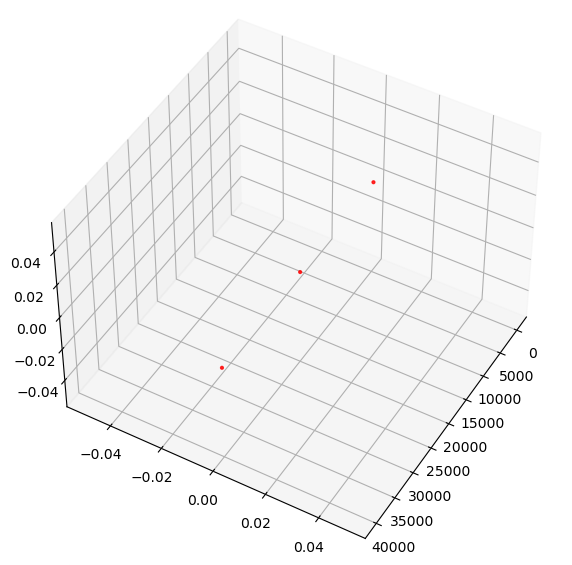

In [6]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
pos = np.array(r_ic)  # Initial positions of the particles
ax.scatter3D(pos[:,0], pos[:,1], pos[:,2], alpha=0.8, s= 4, c='r')
ax.view_init(45,30)

In [7]:
def save_state_to_csv(db, current_time):
    # Create a filename based on the current simulation time, formatted to be sequential, in the folder ../simulation-outputs/1sec10000sec/ (e.g., particle_state_t0010.csv)
    ensure_dir = "../simulation-outputs/1sec10000sec/"
    os.makedirs(ensure_dir, exist_ok=True)
    filename = f"../simulation-outputs/1sec10000sec/particle_state_t{int(current_time):04d}.csv"
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "index", "id", "parent_id", "x", "y", "z", "vx", "vy", "vz",
            "mass", "collision_radius", "char_length", "area_to_mass", "bstar"
        ])
        for idx, p in db.items():
            writer.writerow([
                idx,
                p.id,
                p.parent_id if p.parent_id is not None else "",
                *p.position,
                *p.velocity,
                p.mass,
                p.collision_radius,
                p.char_length,
                p.area_to_mass,
                p.bstar
            ])
    return filename

In [8]:
final_time = 10000
save_interval = 100
next_save_time = 0 

total_collisions_count = 0
next_frag_id = 50000
start_wall_clock = time.time()

for logger_name in logging.root.manager.loggerDict:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

# Initialize the handler
collision_handler = CollisionFragmentHandler(
    min_char_length=MIN_CHARACTERISTIC_LENGTH,
    breakup_model_path=BREAKUP_MODEL_PATH,
    enforce_mass_conservation=ENFORCE_MASS_CONSERVATION
)
collision_handler.set_next_fragment_id(next_frag_id)

print(f"Starting Simulation: {len(particle_db)} objects | Target: {final_time}s")

pbar = tqdm(total=final_time, unit="s", desc="Simulating")

# 2. Main Simulation Loop

while sim.time < final_time:
    
    outcome = sim.step()
    
    # Update progress bar position and description
    pbar.n = min(sim.time, final_time)
    pbar.set_postfix({
        "Objs": len(particle_db), 
        "Cols": total_collisions_count
    })
    pbar.refresh()

    # Sync Python positions
    for i in range(len(sim.state)):
        if i in particle_db:
            particle_db[i].position = sim.state[i, 0:3]
            particle_db[i].velocity = sim.state[i, 3:6]

    # Handle collision if one occurred
    if outcome == csc.outcome.collision:
        pi, pj = sim.interrupt_info
        total_collisions_count += 1
        pbar.write(f"\n[t={sim.time:.4f}s] COLLISION: {particle_db[pi].id} + {particle_db[pj].id}")
        
        num_before_fragments = len(particle_db)
        new_particle_db, particles_to_remove = collision_handler.handle_collision(
            sim, pi, pj, particle_db
        )

        survivor_indices = [i for i in range(num_before_fragments) if i not in particles_to_remove]
        fragment_indices = [i for i in range(num_before_fragments, len(new_particle_db))]
        
        # Drifting Fragments to separate them from the survivors
        if fragment_indices:
            frag_r = np.array([new_particle_db[f_idx].position for f_idx in fragment_indices])
            frag_v = np.array([new_particle_db[f_idx].velocity for f_idx in fragment_indices])
            frag_rad = np.array([new_particle_db[f_idx].collision_radius for f_idx in fragment_indices]).reshape(-1, 1)

            frag_state_matrix = np.column_stack((frag_r, frag_v, frag_rad))
            frag_pars = np.zeros((len(fragment_indices), 0))

            drift_sim = csc.sim(
                frag_state_matrix,
                ct_value,
                dyn=dyn,
                pars=frag_pars
            )
            print(f"  Drifting {len(fragment_indices)} fragments for separation...")
            print(f"Minimum Collision radius among fragments: {frag_rad.min():.2f} m")

            drift_sim.step()

            for i, f_idx in enumerate(fragment_indices):
                new_particle_db[f_idx].position = drift_sim.state[i, 0:3]
                new_particle_db[f_idx].velocity = drift_sim.state[i, 3:6]

        # Rebuild the simulation state
        r_list, v_list, rad_list = [], [], []
        updated_db = {}
        
        for i, old_idx in enumerate(survivor_indices):
            p = new_particle_db[old_idx]
            r_list.append(sim.state[old_idx, 0:3])
            v_list.append(sim.state[old_idx, 3:6])
            rad_list.append(p.collision_radius)
            updated_db[i] = p
            
        curr_idx = len(updated_db)
        for f_idx in fragment_indices:
            f_obj = new_particle_db[f_idx]
            r_list.append(f_obj.position)
            v_list.append(f_obj.velocity)
            rad_list.append(f_obj.collision_radius)
            updated_db[curr_idx] = f_obj
            curr_idx += 1
        
        # Push back to C++
        if len(r_list) > 0:
            final_state = np.column_stack([np.array(r_list), np.array(v_list), np.array(rad_list)])
            if np.isnan(final_state).any():
                pbar.write("FATAL: NaN in state! Gravity calculation failed.")
                break

            empty_bst_list = [[] for _ in range(len(r_list))]
            sim.set_new_state_pars(final_state.tolist(), empty_bst_list)
            
            particle_db = updated_db
            pbar.write(f"Injected {len(fragment_indices)} fragments. Total: {len(particle_db)}")
        else:
            pbar.write("No particles left. Terminating.")
            break

    # Periodic Output Check
    if sim.time >= next_save_time:
        saved_file = save_state_to_csv(particle_db, next_save_time)
        while next_save_time <= sim.time:
            next_save_time += save_interval


pbar.close()

# Ensure the absolute final state is also explicitly saved
save_state_to_csv(particle_db, sim.time)
print(f"Saved final absolute state to CSV.")

Starting Simulation: 3 objects | Target: 10000s


Simulating:   0%|          | 0/10000 [00:00<?, ?s/s]


[t=19.9000s] COLLISION: 1000 + 1001
Running NASA Breakup Model simulation with config: /home/andrea/LSMS_project/NASA-breakup-model-cpp/collision_config.yaml
Simulation completed. Output CSV: /home/andrea/LSMS_project/NASA-breakup-model-cpp/fragments.csv
  Drifting 3700 fragments for separation...
Minimum Collision radius among fragments: 50.00 m
Injected 3700 fragments. Total: 3701

[t=48.3608s] COLLISION: 1002 + 51327
Running NASA Breakup Model simulation with config: /home/andrea/LSMS_project/NASA-breakup-model-cpp/collision_config.yaml
Simulation completed. Output CSV: /home/andrea/LSMS_project/NASA-breakup-model-cpp/fragments.csv
  Drifting 2 fragments for separation...
Minimum Collision radius among fragments: 50.00 m
Injected 2 fragments. Total: 3701

[t=48.6873s] COLLISION: 51513 + 50001
Running NASA Breakup Model simulation with config: /home/andrea/LSMS_project/NASA-breakup-model-cpp/collision_config.yaml
Simulation completed. Output CSV: /home/andrea/LSMS_project/NASA-break

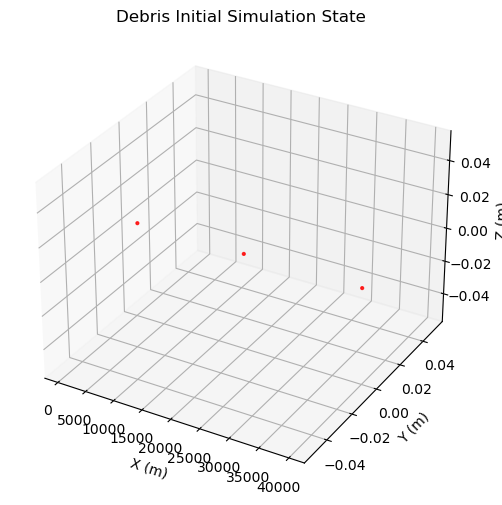

In [10]:
# Test the first csv output
file = "../simulation-outputs/1sec10000sec/particle_state_t0000.csv"
def read_csv_frame(filepath):
    pos, parents = [], []
    with open(filepath, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            pos.append([float(row["x"]), float(row["y"]), float(row["z"])])
            pid = row["parent_id"]
            parents.append(pid if pid != "" else "-1")
    return np.array(pos), np.array(parents)

final_pos, final_parents = read_csv_frame(file)
unique_parents, _ = np.unique(final_parents, return_inverse=True)
parent_color_map = {pid: i for i, pid in enumerate(unique_parents)}

# Determine the absolute max distance to lock the 3D box size
max_val = np.max(np.abs(final_pos)) 

# 3. Setup the Figure
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("Debris Initial Simulation State")
# Initial scatter (will be updated in the animation)
scat = ax.scatter(final_pos[:,0], final_pos[:,1], final_pos[:,2], alpha=0.8, s= 4, c='r')
plt.show()



Generating animation locked to INITIAL state axes...
Initial bounds for column: min=5000001063.74, max=5000193730.00, span=192666.26
Initial bounds for column: min=-7515.77, max=11315.72, span=18831.49
Initial bounds for column: min=-34437.56, max=6297.37, span=40734.92


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


Success! Viewport locked to T=0. Check ../simulation-gifs/simulation-10-1000/debris_propagation.gif


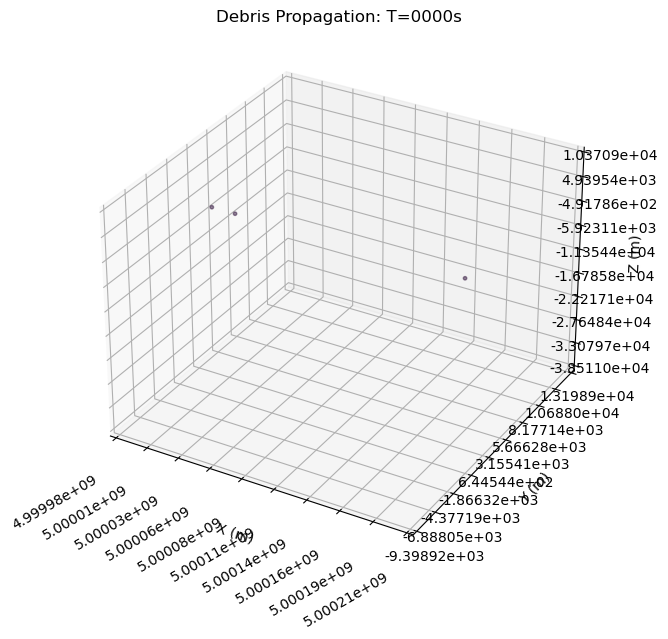

In [ ]:
print("\nGenerating animation locked to INITIAL state axes...")
# Ensure the output folder exists
os.makedirs("../simulation-gifs/simulation-10-1000/", exist_ok=True)

# 1. Find and sort CSV files
csv_files = sorted(glob.glob("../simulation-outputs/10sec1000sec/particle_state_t*.csv"))

def read_csv_frame(filepath):
    pos, parents = [], []
    with open(filepath, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            pos.append([float(row["x"]), float(row["y"]), float(row["z"])])
            pid = row["parent_id"]
            parents.append(pid if pid != "" else "-1")
    return np.array(pos), np.array(parents)

# 2. Get limits and color map from the INITIAL file (t0000)
initial_pos, initial_parents = read_csv_frame(csv_files[2])

# Determine limits 
def get_initial_bounds(data_column, pad=0.1):
    vmin, vmax = np.min(data_column), np.max(data_column)
    span = vmax - vmin
    if span == 0: span = 1.0 # prevents crash if all points have same coord
    print(f"Initial bounds for column: min={vmin:.2f}, max={vmax:.2f}, span={span:.2f}")
    return [vmin - span*pad, vmax + span*pad]

INIT_XLIM = get_initial_bounds(initial_pos[:,0])
INIT_YLIM = get_initial_bounds(initial_pos[:,1])
INIT_ZLIM = get_initial_bounds(initial_pos[:,2])

# Pre-define the color map using ALL parents found across the whole sim

all_unique_parents = set()
for f in csv_files:
    _, p = read_csv_frame(f)
    all_unique_parents.update(p)
unique_parents_list = sorted(list(all_unique_parents))
parent_color_map = {pid: i for i, pid in enumerate(unique_parents_list)}
# 3. Setup the Figure
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

def update(frame_idx):
    ax.clear()
    filepath = csv_files[frame_idx]
    pos, parents = read_csv_frame(filepath)

    if len(pos) > 0:
        c_indices = np.array([parent_color_map.get(p, 0) for p in parents])
        ax.scatter(
            pos[:,0], pos[:,1], pos[:,2],
            alpha=0.5, s=6,
            c=c_indices, cmap='turbo',
            vmin=0, vmax=max(1, len(unique_parents_list)-1)
        )
    # FORCE THE AXES TO THE INITIAL STATE BOUNDS
    ax.set_xlim(INIT_XLIM)
    ax.set_ylim(INIT_YLIM)
    ax.set_zlim(INIT_ZLIM)

    # Labels
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")

    # Ticks
    ax.set_xticks(np.linspace(INIT_XLIM[0], INIT_XLIM[1], 10))
    ax.set_yticks(np.linspace(INIT_YLIM[0], INIT_YLIM[1], 10))
    ax.set_zticks(np.linspace(INIT_ZLIM[0], INIT_ZLIM[1], 10))

    # 1. Disable the scientific notation offset (the "multiplier" at the end of the axis)
    ax.xaxis.get_major_formatter().set_useOffset(False)
    ax.yaxis.get_major_formatter().set_useOffset(False)
    ax.zaxis.get_major_formatter().set_useOffset(False)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.5e'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.5e'))
    ax.zaxis.set_major_formatter(FormatStrFormatter('%.5e'))
    # 3. Rotate labels if they overlap
    ax.tick_params(axis='x', pad=10)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    # Re-extract time for title
    filename = os.path.basename(filepath)
    time_str = filename.replace("particle_state_t", "").replace(".csv", "")
    ax.set_title(f"Debris Propagation: T={time_str}s")
# 4. Save
ani = animation.FuncAnimation(fig, update, frames=len(csv_files), interval=500)
output_filename = "../simulation-gifs/simulation-10-1000/debris_propagation.gif"
ani.save(output_filename, writer='pillow', fps=5)
print(f"Success! Viewport locked to T=0. Check {output_filename}")